# Sanity check — errores en test set

Análisis cualitativo y cuantitativo de clasificaciones incorrectas con los mejores modelos (`models/temas`, `models/carga-phase3`).

Equivalente a `python scripts/show_misclassified.py`.

In [10]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "config.yml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import importlib
import mindful_news.training.data as _data
import mindful_news.training.preprocess as _preprocess

importlib.reload(_preprocess)
importlib.reload(_data)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

import importlib
import mindful_news.training.evaluate as _evaluate
importlib.reload(_evaluate)

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from mindful_news.training.evaluate import _default_model_dir, predict_test_errors

TASKS = ["temas", "carga"]
results = {}
for task in TASKS:
    frame = predict_test_errors(task)
    results[task] = frame
    errors = (~frame["correct"]).sum()
    print(f"{task}: {errors}/{len(frame)} errores ({errors/len(frame):.1%}) | model={_default_model_dir(task)}")


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

temas: 409/1801 errores (22.7%) | model=C:\Users\arihs\Code\mlprod-obligatorio\models\temas-phase4


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

carga: 372/1801 errores (20.7%) | model=C:\Users\arihs\Code\mlprod-obligatorio\models\carga-phase3


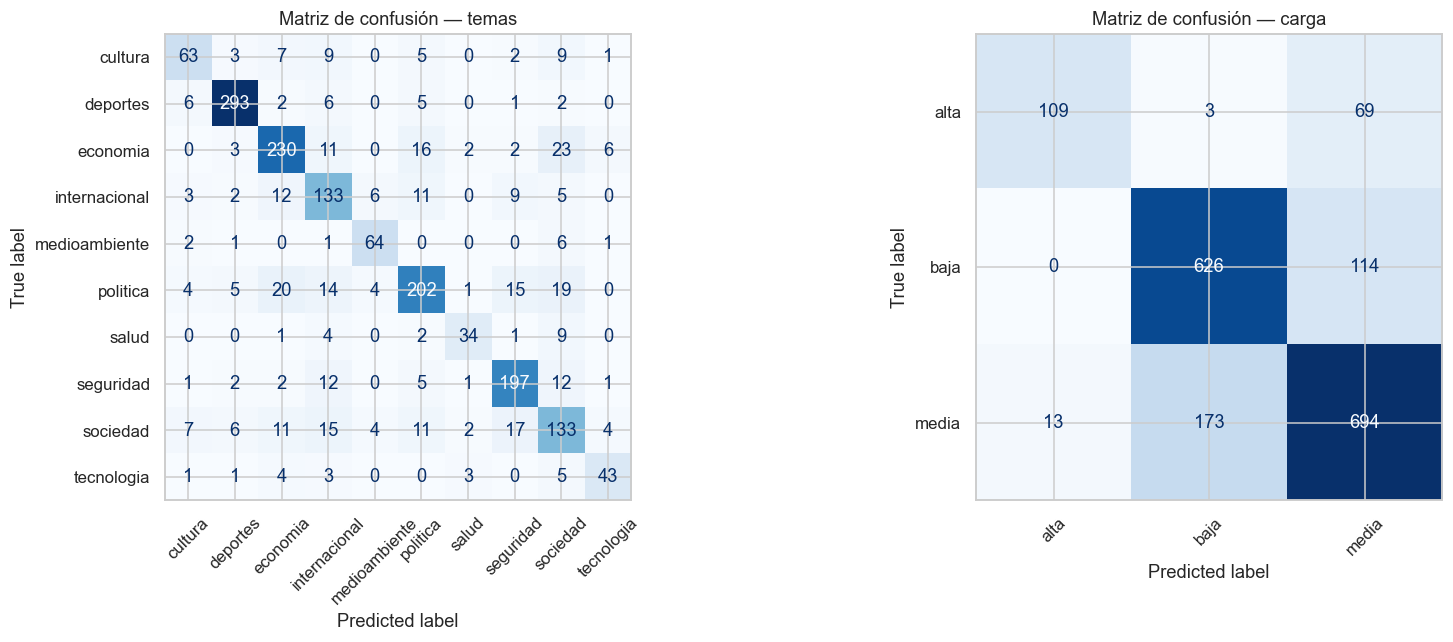

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, task in zip(axes, TASKS):
    frame = results[task]
    labels = sorted(frame["true_label"].unique())
    cm = confusion_matrix(frame["true_label"], frame["pred_label"], labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    ax.set_title(f"Matriz de confusión — {task}")

plt.tight_layout()
plt.show()


In [12]:
def top_confusion_pairs(frame: pd.DataFrame, n: int = 10) -> pd.DataFrame:
    errors = frame[~frame["correct"]]
    pairs = (
        errors.groupby(["true_label", "pred_label"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    return pairs.head(n)


for task in TASKS:
    print(f"\n=== {task.upper()} — pares más frecuentes ===")
    display(top_confusion_pairs(results[task]))



=== TEMAS — pares más frecuentes ===


,true_label,pred_label,count
18,economia,sociedad,23
34,politica,economia,20
39,politica,sociedad,19
60,sociedad,seguridad,17
15,economia,politica,16
56,sociedad,internacional,15
38,politica,seguridad,15
35,politica,internacional,14
51,seguridad,sociedad,12
22,internacional,economia,12



=== CARGA — pares más frecuentes ===


,true_label,pred_label,count
4,media,baja,173
2,baja,media,114
1,alta,media,69
3,media,alta,13
0,alta,baja,3


c:\Users\arihs\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\arihs\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\arihs\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\arihs\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a len

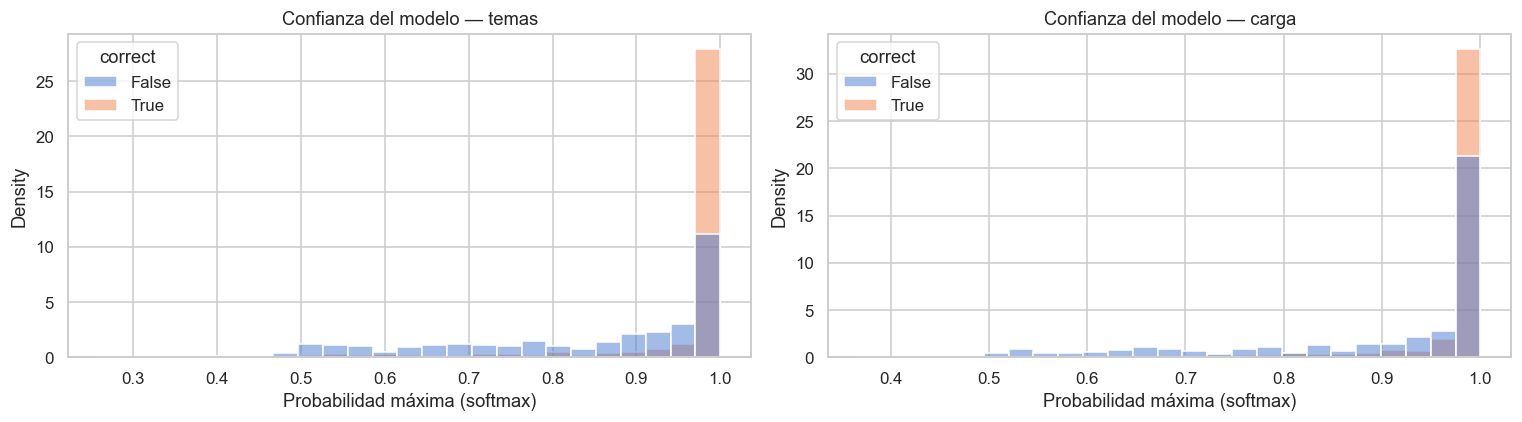

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, task in zip(axes, TASKS):
    frame = results[task]
    sns.histplot(
        data=frame,
        x="confidence",
        hue="correct",
        bins=25,
        stat="density",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(f"Confianza del modelo — {task}")
    ax.set_xlabel("Probabilidad máxima (softmax)")

plt.tight_layout()
plt.show()


In [14]:
def show_examples(frame: pd.DataFrame, n: int = 8) -> pd.DataFrame:
    errors = frame[~frame["correct"]].head(n)
    cols = ["true_label", "pred_label", "confidence", "medio", "split_date", "titulo", "url"]
    return errors[cols]


for task in TASKS:
    print(f"\n=== {task.upper()} — ejemplos mal clasificados (alta confianza) ===")
    display(show_examples(results[task]))



=== TEMAS — ejemplos mal clasificados (alta confianza) ===


,true_label,pred_label,confidence,medio,split_date,titulo,url
991,sociedad,internacional,0.999997,El Observador,2026-06-01 12:39:00,Hungría reactiva la marcha del Orgullo LGBT en...,https://www.elobservador.com.uy/espana/sucede/...
1556,economia,deportes,0.999997,El Observador,2026-06-04 09:10:00,Reventa mundialista: piden fortunas por palcos...,https://www.elobservador.com.uy/espana/economi...
1402,politica,economia,0.999992,El País,2026-06-03 17:41:17,"Parlamento aprueba Uruguay Impulsa, programa c...",https://www.elpais.com.uy/informacion/politica...
472,tecnologia,salud,0.999991,El Observador,2026-05-29 05:00:00,"Inteligencia artificial, sensores y diagnóstic...",https://www.elobservador.com.uy/brand-studio/i...
1454,sociedad,deportes,0.999991,La Diaria,2026-06-03 21:34:27,Uruguay recibirá el Pabellón Nacional de manos...,https://ladiaria.com.uy/deporte/articulo/2026/...
1580,politica,deportes,0.999973,El Observador,2026-06-04 10:08:00,Elecciones en el Real Madrid: Riquelme promete...,https://www.elobservador.com.uy/espana/relax/e...
13,seguridad,cultura,0.999960,El Observador,2026-05-26 13:56:00,Con exhibiciones de Masha y el oso y ¿Quién so...,https://www.elobservador.com.uy/nacional/con-e...
436,sociedad,seguridad,0.999958,El Observador,2026-05-28 20:37:00,"Encuesta de Equipos muestra ""incremento signif...",https://www.elobservador.com.uy/nacional/hubo-...



=== CARGA — ejemplos mal clasificados (alta confianza) ===


,true_label,pred_label,confidence,medio,split_date,titulo,url
552,media,baja,1.000000,El Observador,2026-05-29 12:19:00,La línea G de Coetc dejará de existir y recupe...,https://www.elobservador.com.uy/nacional/la-li...
1736,media,baja,1.000000,El País,2026-06-04 18:53:00,Papelón en los Influencers Awards Uruguay: dos...,https://www.elpais.com.uy/tvshow/personajes/pa...
1306,media,baja,0.999999,La Diaria,2026-06-03 10:11:07,Horacio Merlo: “La cultura siempre es la cenic...,https://ladiaria.com.uy/paysandu/articulo/2026...
832,media,baja,0.999999,La Diaria,2026-06-01 00:00:00,El Fondo Nacional de Recursos como fondo marca...,https://ladiaria.com.uy/economia/articulo/2026...
674,media,baja,0.999999,El Observador,2026-05-30 11:47:00,Muere a los 104 años el filósofo francés Edgar...,https://www.elobservador.com.uy/espana/sucede/...
1786,baja,media,0.999996,La Diaria,2026-06-04 22:52:56,Gobierno inició proceso para eximir de visas a...,https://ladiaria.com.uy/politica/articulo/2026...
167,media,baja,0.999993,Montevideo Portal,2026-05-27 11:39:00,Fratti: “Homenaje a Mujica se lo hacemos a dia...,https://www.montevideo.com.uy/Noticias/Fratti-...
701,baja,media,0.999992,El Observador,2026-05-30 16:54:00,"""Cuando hay descuentos yo me tiro de cabeza"", ...",https://www.elobservador.com.uy/nacional/cuand...


In [15]:
# Errores con baja confianza (el modelo duda)
LOW_CONF = 0.55

for task in TASKS:
    frame = results[task]
    borderline = frame[(~frame["correct"]) & (frame["confidence"] < LOW_CONF)].sort_values("confidence")
    print(f"\n{task}: {len(borderline)} errores con confianza < {LOW_CONF}")
    if not borderline.empty:
        display(borderline[["true_label", "pred_label", "confidence", "titulo"]].head(8))



temas: 37 errores con confianza < 0.55


,true_label,pred_label,confidence,titulo
559,cultura,deportes,0.259763,IMPO renueva su pantalla gigante de 18 de Juli...
730,economia,sociedad,0.278408,"Patricia Jebsen, de la cumbre corporativa a in..."
1368,seguridad,internacional,0.355320,"Esto es cine: pescadores naufragaron, un surfi..."
534,cultura,internacional,0.366195,El negocio de Marilyn Monroe: quién gana diner...
1320,deportes,politica,0.391326,"""Vamos por la quinta"": el productor del video ..."
156,seguridad,sociedad,0.416782,Dos argentinos terminaron en CTI tras chocar c...
1579,seguridad,deportes,0.449321,Suspendieron la práctica de los niños de AUFI ...
1300,tecnologia,economia,0.456486,"Así es Pathfinder, el 'espía' israelí de Hacienda"



carga: 13 errores con confianza < 0.55


,true_label,pred_label,confidence,titulo
1637,alta,media,0.368355,"A los 56 años murió ""de tristeza"" Marjane Satr..."
86,media,baja,0.501809,Jefe de la Zona Operacional IV de Montevideo f...
718,media,baja,0.503743,La Economía del Fastidio le cuesta a cada hoga...
1530,media,baja,0.504257,Bergara va por una mayoría especial: IMM ajust...
1198,media,baja,0.517958,“Nos vemos afuera”: qué pasó tras cruce entre ...
1680,media,alta,0.521624,El sherpa dado por muerto en el Everest que fu...
1681,media,alta,0.521624,El sherpa dado por muerto en el Everest que fu...
874,media,baja,0.529983,diputado gorosterrazu cree que intendentes apo...


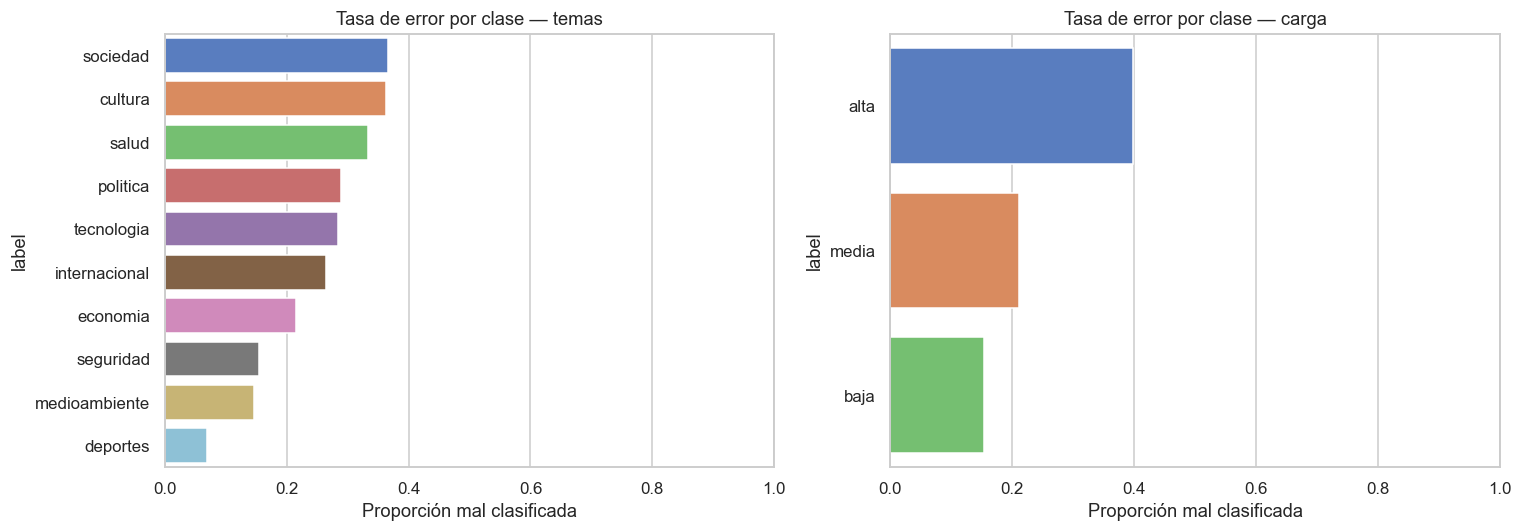

In [16]:
# Tasa de error por etiqueta verdadera
rows = []
for task, frame in results.items():
    for label, group in frame.groupby("true_label"):
        err_rate = (~group["correct"]).mean()
        rows.append({"task": task, "label": label, "error_rate": err_rate, "support": len(group)})

error_by_label = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task in zip(axes, TASKS):
    subset = error_by_label[error_by_label["task"] == task].sort_values("error_rate", ascending=False)
    sns.barplot(data=subset, x="error_rate", y="label", ax=ax, orient="h")
    ax.set_xlim(0, 1)
    ax.set_title(f"Tasa de error por clase — {task}")
    ax.set_xlabel("Proporción mal clasificada")

plt.tight_layout()
plt.show()


In [17]:
# Export opcional (descomentar)
# out = ROOT / "data" / "exports" / "test_errors_notebook.csv"
# combined = []
# for task, frame in results.items():
#     part = frame[~frame["correct"]].copy()
#     part.insert(0, "task", task)
#     combined.append(part)
# pd.concat(combined, ignore_index=True).to_csv(out, index=False)
# print("Exportado:", out)


## Input del modelo: sección + título

Desde la **fase 4 de tuning (temas)** el clasificador ya no ve solo el titular. El texto que entra a mmBERT se arma así:

```
{seccion} | {titulo}
```

Ejemplo real:

> `Noticias, Policiales | Dos veces en dos semanas: balearon casa en Jardines del Hipódromo`

**Por qué:** la sección del medio (cuando existe) ayuda a desambiguar temas (`deporte`→deportes, `Noticias, Policiales`→seguridad). En el dataset, **99.98%** de titulares tienen `seccion`; si falta, se usa solo el título.

**Config** (`config.yml` → `training.input`):
- `include_seccion: true`
- `separator: " | "`
- `template: "{seccion}{sep}{titulo}"`

**Tuning fase 4:** 30 trials Optuna solo para **temas**, con anchor del ganador de fase 1. Modelo final en `models/temas-phase4/`. W&B group: `temas-optuna-v4`.

**Compatibilidad:** modelos viejos (solo título) guardan `input_text_mode: titulo` en `metrics.json`; la inferencia respeta eso. Los nuevos guardan `seccion_titulo`.

> Si ves `ImportError` tras editar código, **reiniciá el kernel** y corré desde la celda 1.

In [18]:
import importlib
import mindful_news.training.data as data_mod
import mindful_news.training.preprocess as preprocess_mod

importlib.reload(preprocess_mod)
importlib.reload(data_mod)

sample = data_mod.prepare_task_frame(data_mod.load_splits()["test"], "temas").head(5)
sample[["seccion", "titulo", "input_text", "tema"]]


,seccion,titulo,input_text,tema
0,copa-libertadores,Peñarol le pidió al Ministerio del Interior ca...,copa-libertadores | Peñarol le pidió al Minist...,deportes
1,bbc-news-mundo,"El ""álbum mundialista de desaparecidos"" de un ...","bbc-news-mundo | El ""álbum mundialista de desa...",internacional
2,"Noticias, Policiales",“Respeten al narcotráfico”: intimidante mensaj...,"Noticias, Policiales | “Respeten al narcotráfi...",seguridad
3,estados-unidos,"México: migrar, una caravana desde adentro","estados-unidos | México: migrar, una caravana ...",internacional
4,nacional,Investigan amenaza narco en el Hospital del Ce...,nacional | Investigan amenaza narco en el Hosp...,seguridad


In [19]:
# Comparar formato de input (si existe modelo fase 4)
import json

phase4_best = ROOT / "data" / "tuning" / "temas_phase4_best.json"
phase1_best = ROOT / "data" / "tuning" / "temas_best.json"

for label, path in [("Fase 1 (solo título)", phase1_best), ("Fase 4 (sección+título)", phase4_best)]:
    if not path.exists():
        print(f"{label}: aún no disponible ({path.name})")
        continue
    best = json.loads(path.read_text(encoding="utf-8"))
    test = best.get("final_test_metrics", {})
    print(
        f"{label} | trial {best.get('trial_number')} | "
        f"val F1={best.get('val_f1_macro', 0):.3f} | "
        f"test F1={test.get('test_f1_macro', 0):.3f}"
    )
    print(f"  model_dir: {best.get('final_model_dir')}")


Fase 1 (solo título) | trial 14 | val F1=0.780 | test F1=0.742
  model_dir: C:\Users\arihs\Code\mlprod-obligatorio\models\temas
Fase 4 (sección+título) | trial 29 | val F1=0.798 | test F1=0.757
  model_dir: C:\Users\arihs\Code\mlprod-obligatorio\models\temas-phase4
